In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv("D:\\Github Repos\\Ticket_Distribution_System\\dataset\\tickets.csv")  # column name: 'ticket'
df.reset_index(drop=True, inplace=True)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Problem Statement  1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,Problem Statement
count,1000
unique,1000
top,I am currently enrolled in the 'Digital Market...
freq,1


#### LLM Summarization (Hugging Face)

In [5]:
from transformers import pipeline
from transformers.pipelines import get_supported_tasks

def make_summarizer():
    supported = get_supported_tasks()
    # prefer the dedicated summarization task when available
    if "summarization" in supported:
        try:
            return pipeline("summarization", model="facebook/bart-large-cnn")
        except Exception as e:
            print("summarization pipeline failed:", e)
    # fallback to text2text-generation (e.g. flan-t5)
    if "text2text-generation" in supported:
        try:
            return pipeline("text2text-generation", model="google/flan-t5-small")
        except Exception as e:
            print("text2text-generation fallback failed:", e)
    # final fallback: no pipeline available, use None (extractive will handle it)
    print("No supported summarization pipeline found. Using extractive fallback.")
    return None

summarizer = make_summarizer()

def summarize_text(text):
    """Summarize a ticket text. Falls back to extractive (first sentence) if no model."""
    if summarizer is None:
        # Extractive fallback: return the first sentence (up to 200 chars)
        first_sentence = text.split('.')[0].strip()
        return first_sentence[:200] if first_sentence else text[:200]
    try:
        summary = summarizer(text, max_length=30, min_length=10, do_sample=False)
        # different pipelines return different keys; handle both common cases
        if isinstance(summary, list) and len(summary) > 0:
            first = summary[0]
            if isinstance(first, dict) and 'summary_text' in first:
                return first['summary_text']
            if isinstance(first, dict) and 'generated_text' in first:
                return first['generated_text']
            return str(first)
        return str(summary)
    except Exception:
        # Extractive fallback on any runtime error
        first_sentence = text.split('.')[0].strip()
        return first_sentence[:200] if first_sentence else text[:200]


d:\Github Repos\Ticket_Distribution_System\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No supported summarization pipeline found. Using extractive fallback.


In [6]:
df['summary'] = df['Problem Statement'].apply(summarize_text)


#### Generate Embeddings

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode summaries → 2-D float32 numpy array (n_samples × 384)
embeddings = embed_model.encode(
    df['summary'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Embeddings shape: {embeddings.shape}")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5519.31it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:03<00:00,  8.21it/s]


Embeddings shape: (1000, 384)


#### HDBSCAN

In [8]:
import hdbscan

# Cluster directly on the high-dim embedding vectors
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean', prediction_data=True)
df['cluster'] = clusterer.fit_predict(embeddings)

n_clusters = df['cluster'].nunique() - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()
print(f"Clusters found: {n_clusters}  |  Noise points: {n_noise}")


Clusters found: 9  |  Noise points: 0


#### Inspect Clusters

#### PCA Cluster Visualisation

Explained variance ratio: [0.211 0.188]  (total 39.9%)


C:\Users\ksb40\AppData\Local\Temp\ipykernel_13260\2366084733.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', max(unique_l.max() + 1, 1))


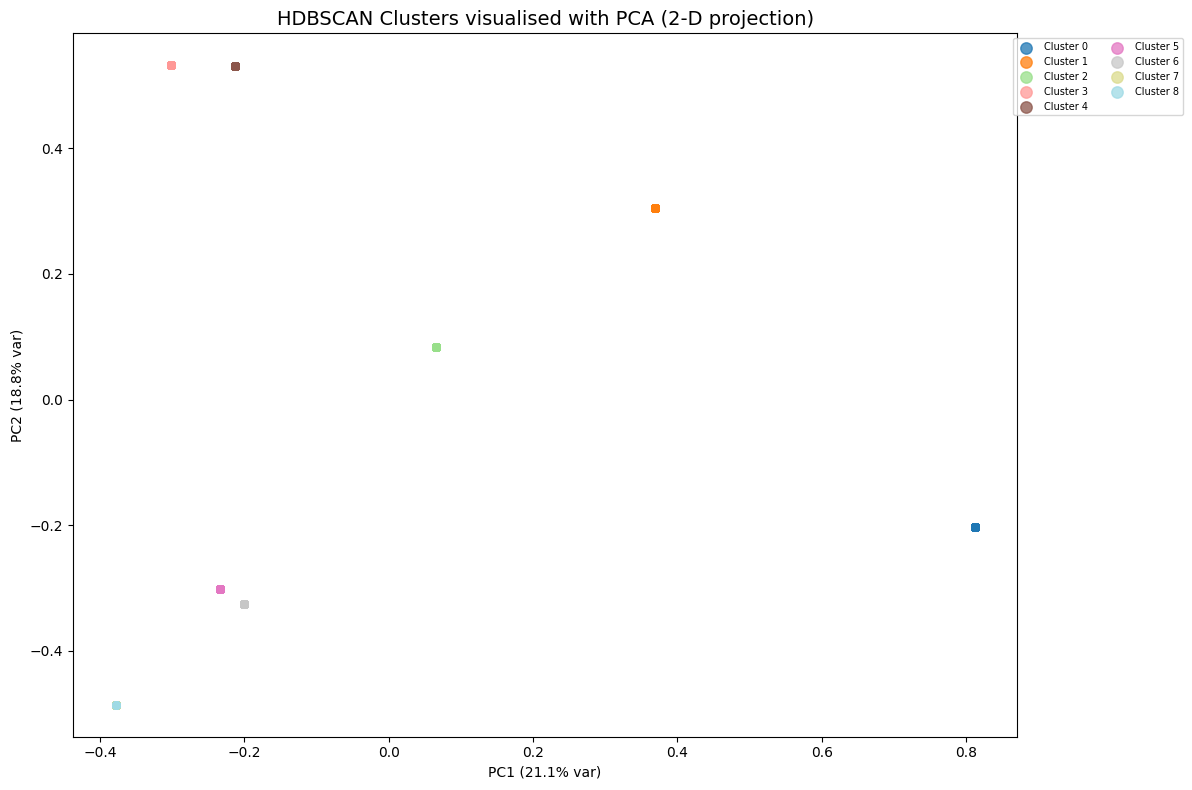

Plot saved to cluster_pca.png


In [9]:
# PCA Cluster Visualisation
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce to 2-D for plotting
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}  "
      f"(total {pca.explained_variance_ratio_.sum():.1%})")

labels   = df['cluster'].values
unique_l = np.unique(labels)

# Colour palette: grey for noise (-1), distinct colours for clusters
cmap   = plt.cm.get_cmap('tab20', max(unique_l.max() + 1, 1))
colors = {l: 'lightgrey' if l == -1 else cmap(l) for l in unique_l}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot noise first (background)
mask_noise = labels == -1
if mask_noise.any():
    ax.scatter(coords[mask_noise, 0], coords[mask_noise, 1],
               c='lightgrey', s=15, alpha=0.4, label='Noise (-1)')

# Plot each cluster
for l in sorted(unique_l):
    if l == -1:
        continue
    mask = labels == l
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[colors[l]], s=30, alpha=0.75, label=f'Cluster {l}')

ax.set_title('HDBSCAN Clusters visualised with PCA (2-D projection)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=7,
          ncol=2, markerscale=1.5)
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to cluster_pca.png")


In [10]:
for c in set(df['cluster']):
    print(f"\nCluster {c}")
    print(df[df['cluster'] == c]['Problem Statement'].head(5).tolist())


Cluster 0
["I noticed a charge on my credit card statement this morning for $149.99 which appears to be a yearly subscription renewal for your platform. However, I am fairly certain that I disabled the auto-renew feature in my profile settings three months ago because I am finishing my degree this semester. I would like to request a full refund for this unauthorized charge as I do not intend to use the service for another year. Could you please look into my billing history and confirm that the refund has been processed? I've been a loyal subscriber for over a year now and usually love the platform, but this recent experience has been quite disappointing. I hope we can resolve this quickly so I can get back to my studies without any further delays. Please let me know if you need any additional information from my side like screenshots or account IDs. Problem occurred at 12:35 AM today. [Ticket ID: 600836]", 'I noticed a charge on my credit card statement this morning for $149.99 which 

In [11]:
# Prepare Cluster Samples


clusters = df.groupby('cluster')['summary'].apply(list)

def get_samples(texts, n=5):
    return texts[:n]

In [12]:
from transformers import pipeline
from transformers.pipelines import get_supported_tasks

# Use text2text-generation if available, else text-generation, else keyword fallback
_supported = get_supported_tasks()

if 'text2text-generation' in _supported:
    _label_task  = 'text2text-generation'
    _label_model = 'google/flan-t5-base'
elif 'text-generation' in _supported:
    _label_task  = 'text-generation'
    _label_model = 'gpt2'
else:
    _label_task  = None
    _label_model = None

if _label_task:
    classifier = pipeline(_label_task, model=_label_model)
else:
    classifier = None

def label_cluster(samples):
    prompt = (
        "These are customer support queries:\n"
        + "\n".join(f'- {s}' for s in samples)
        + "\n\nWhat is the common category? (1-2 words only)"
    )
    if classifier is None:
        # keyword fallback: pick most frequent first meaningful word
        from collections import Counter
        import re
        stopwords = {'i','am','the','a','an','my','to','for','in','of','and','is',
                     'on','it','this','that','have','has','but','not','be','with'}
        words = re.findall(r'[a-zA-Z]+', ' '.join(samples).lower())
        filtered = [w for w in words if w not in stopwords and len(w) > 3]
        top = Counter(filtered).most_common(2)
        return ' '.join(w for w, _ in top) if top else 'General'
    result = classifier(prompt, max_length=50, truncation=True)
    return result[0].get('generated_text', result[0].get('summary_text', 'General'))


d:\Github Repos\Ticket_Distribution_System\myvenv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ksb40\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5833.80it/s]


In [13]:
cluster_labels = {}

for cluster_id, texts in clusters.items():
    if cluster_id == -1:
        cluster_labels[cluster_id] = "Other"
        continue
        
    samples = get_samples(texts)
    label = label_cluster(samples)
    
    cluster_labels[cluster_id] = label

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_len

In [14]:
# Map Back

df['team'] = df['cluster'].map(cluster_labels)

In [15]:
# Save Output
import os

output_path = 'output.xlsx'

try:
    # openpyxl required for .xlsx
    df.to_excel(output_path, index=False, engine='openpyxl')
    size_kb = os.path.getsize(output_path) / 1024
    print(f"Saved → {output_path}  ({size_kb:.1f} KB, {len(df)} rows, {df.shape[1]} columns)")
    print(f"Columns: {df.columns.tolist()}")
except ModuleNotFoundError:
    # fallback to CSV if openpyxl is missing
    output_path = 'output.csv'
    df.to_csv(output_path, index=False)
    size_kb = os.path.getsize(output_path) / 1024
    print(f"openpyxl not found — saved as CSV instead: {output_path}  ({size_kb:.1f} KB)")


openpyxl not found — saved as CSV instead: output.csv  (2884.6 KB)


In [17]:
#Streamlit UI

import streamlit as st
import pandas as pd
from sentence_transformers import SentenceTransformer
import hdbscan
from transformers import pipeline

st.title("🎯 Ticket Routing System")

uploaded_file = st.file_uploader("Upload Excel File", type=["xlsx"])

if uploaded_file:
    df = pd.read_excel(uploaded_file)
    
    st.write("Data Preview:", df.head())

    # Summarization
    from transformers.pipelines import get_supported_tasks

    def make_summarizer():
        supported = get_supported_tasks()
        if "summarization" in supported:
            try:
                return pipeline("summarization", model="facebook/bart-large-cnn")
            except Exception as e:
                print("summarization pipeline failed:", e)
        try:
            return pipeline("text2text-generation", model="google/flan-t5-small")
        except Exception as e:
            print("text2text-generation fallback failed:", e)
            raise

    summarizer = make_summarizer()

    def summarize_text(text):
        try:
            summary = summarizer(text, max_length=30, min_length=10, do_sample=False)
            if isinstance(summary, list) and len(summary) > 0:
                first = summary[0]
                if isinstance(first, dict) and 'summary_text' in first:
                    return first['summary_text']
                if isinstance(first, dict) and 'generated_text' in first:
                    return first['generated_text']
                return str(first)
            return str(summary)
        except Exception:
            return text

    df['summary'] = df['ticket'].apply(summarize_text)

    # Embeddings
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embed_model.encode(df['summary'].tolist())

    # Clustering
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
    df['cluster'] = clusterer.fit_predict(embeddings)

    # Label clusters
    classifier = pipeline("text2text-generation", model="google/flan-t5-base")

    clusters = df.groupby('cluster')['summary'].apply(list)

    def label_cluster(samples):
        prompt = f"""
        These are customer queries:
        {samples}
        Give category name (1-2 words only)
        """
        return classifier(prompt, max_length=50)[0]['generated_text']

    cluster_labels = {}
    
    for cluster_id, texts in clusters.items():
        if cluster_id == -1:
            cluster_labels[cluster_id] = "Other"
        else:
            cluster_labels[cluster_id] = label_cluster(texts[:5])

    df['team'] = df['cluster'].map(cluster_labels)

    st.write("Processed Data:", df.head())

    output_file = "output.xlsx"
    df.to_excel(output_file, index=False)

    with open(output_file, "rb") as f:
        st.download_button("Download Output", f, file_name="output.xlsx")

2026-04-14 00:12:15.552 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.675 
  command:

    streamlit run d:\Github Repos\Ticket_Distribution_System\myvenv\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-14 00:12:15.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 00:12:15.68